# Modélisation 

In [20]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import bentoml
from bentoml.io import NumpyNdarray
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.model_selection import cross_validate
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [21]:
# ==============================================================
# 🧠 Fonction d'évaluation modèle
# ==============================================================

def evaluate_model(name, model, X_train, y_train, X_test, y_test, cv=5):
    """
    Entraîne, évalue et compare un modèle.
    Retourne un dictionnaire de résultats.
    """
    # --- Cross-validation sur le jeu d'entraînement ---
    cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring='r2', return_train_score=True)
    
    # --- Entraînement sur tout le jeu d'entraînement ---
    model.fit(X_train, y_train)
    
    # --- Évaluation sur le jeu d'entraînement ---
    y_train_pred = model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # --- Évaluation sur le jeu de test ---
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # --- Résumé ---
    print(f"\n=== {name} ===")
    print(f"CV R² moyen : {cv_results['test_score'].mean():.3f} (+/- {cv_results['test_score'].std():.3f})")
    print(f"Train R² : {train_r2:.3f} | Test R² : {test_r2:.3f}")
    print(f"Test MAE : {test_mae:,.0f} | Test RMSE : {test_rmse:,.0f}")
    
    return {
        "Modèle": name,
        "CV_R2_Moyen": cv_results['test_score'].mean(),
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse
    }

In [22]:
# Chargement
df_filtré = pd.read_parquet("mon_dataset.parquet", engine="pyarrow")
buildings_initial = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

# 🔧 Feature Engineering

Dans cette partie, nous allons enrichir notre dataset avec des informations utiles pour le modèle, sans introduire de fuite de données (*data leakage*).  
L’objectif est de créer des features structurelles, liées au type d’usage et à la localisation du bâtiment.

---

### 1️⃣ Features structurelles

- **Surface totale** : `PropertyGFATotal`  
- **Nombre d’étages** : `NumberofFloors`  
- **Âge du bâtiment** : calculé comme `Age = DataYear - YearBuilt`


In [23]:
# Sélectionner uniquement les colonnes à ajouter
colonnes_a_ajouter =  ["LargestPropertyUseType", "NumberofFloors", "Neighborhood", "DataYear","NumberofBuildings","PropertyGFAParking","LargestPropertyUseTypeGFA"]

In [24]:
# Fusionner avec df_filtré sur l'ID du bâtiment
df_filtré = df_filtré.merge(buildings_initial[["OSEBuildingID"] + colonnes_a_ajouter],
                            on="OSEBuildingID",
                            how="left")

#### Création de nouvelles features

 On peut créer plusieurs types de features :
- **Structurelles** : nombre d'étages, type principal d'usage
- **Temporelles** : âge du bâtiment
- **Localisation** : quartier (Neighborhood)

On évite toute feature basée sur la consommation d'énergie pour éviter le data leakage.


In [25]:
display(df_filtré.shape)

(1309, 12)

In [26]:
# 🏗️ 1. Âge du bâtiment
df_filtré["BuildingAge"] = df_filtré["DataYear"] - df_filtré["YearBuilt"]

# 📏 2. Surface par étage (densité verticale)
df_filtré["SurfaceParEtage"] = df_filtré["PropertyGFATotal"] / df_filtré["NumberofFloors"]
df_filtré["SurfaceParEtage"] = df_filtré["SurfaceParEtage"].replace([np.inf, -np.inf], np.nan).fillna(df_filtré["SurfaceParEtage"].median())

# 🏢 3. Catégorisation des bâtiments selon le nombre d’étages
df_filtré["SmallBuilding"] = (df_filtré["NumberofFloors"] <= 3).astype(int)
df_filtré["MediumBuilding"] = ((df_filtré["NumberofFloors"] > 3) & (df_filtré["NumberofFloors"] <= 10)).astype(int)
df_filtré["TallBuilding"] = (df_filtré["NumberofFloors"] > 10).astype(int)
# ❌ Suppression de la colonne originale
df_filtré.drop(columns=["NumberofFloors","DataYear","YearBuilt"], inplace=True)


In [27]:
display(df_filtré.shape)

(1309, 14)

In [28]:

# 1️⃣ Densité de bâtiment — rapport entre surface totale et surface parking

df_filtré["BuildingDensity"] = np.where(
    (df_filtré["PropertyGFAParking"] > 0),
    df_filtré["PropertyGFATotal"] / df_filtré["PropertyGFAParking"],
   0  # pas de parking => pas de densité
)


# 2️⃣ Catégorie d'âge
df_filtré["AgeCategory"] = pd.cut(
    df_filtré["BuildingAge"],
    bins=[0, 20, 50, np.inf],
    labels=["Neuf", "Moyen", "Vieux"],
    right=False)
# ✅ Indicateur de présence de parking
df_filtré["HasParking"] = (df_filtré["PropertyGFAParking"] > 0).astype(int)


In [29]:
df_filtré.shape

(1309, 17)

## Correlations entre Feautures / target

In [30]:
target = "SiteEnergyUseWN(kBtu)"
# Sélectionner toutes les colonnes numériques
numeric_cols = df_filtré.select_dtypes(include=["number"]).columns.tolist()

# Retirer la target
features_num = [col for col in numeric_cols if col != target]
display(features_num)

['OSEBuildingID',
 'PropertyGFATotal',
 'NumberofBuildings',
 'PropertyGFAParking',
 'LargestPropertyUseTypeGFA',
 'BuildingAge',
 'SurfaceParEtage',
 'SmallBuilding',
 'MediumBuilding',
 'TallBuilding',
 'BuildingDensity',
 'HasParking']

Matrice de corrélation :
                            OSEBuildingID  PropertyGFATotal  NumberofBuildings  \
OSEBuildingID                   1.000000         -0.517152           0.021849   
PropertyGFATotal               -0.517152          1.000000           0.028642   
NumberofBuildings               0.021849          0.028642           1.000000   
PropertyGFAParking             -0.212191          0.519578           0.004378   
LargestPropertyUseTypeGFA      -0.423402          0.872529           0.059574   
BuildingAge                    -0.096997         -0.159122          -0.078998   
SurfaceParEtage                -0.270981          0.424719           0.077967   
SmallBuilding                   0.313785         -0.477356           0.033548   
MediumBuilding                 -0.285289          0.412062          -0.024057   
TallBuilding                   -0.110917          0.233072          -0.030752   
BuildingDensity                -0.169592          0.212748          -0.012032   
Ha

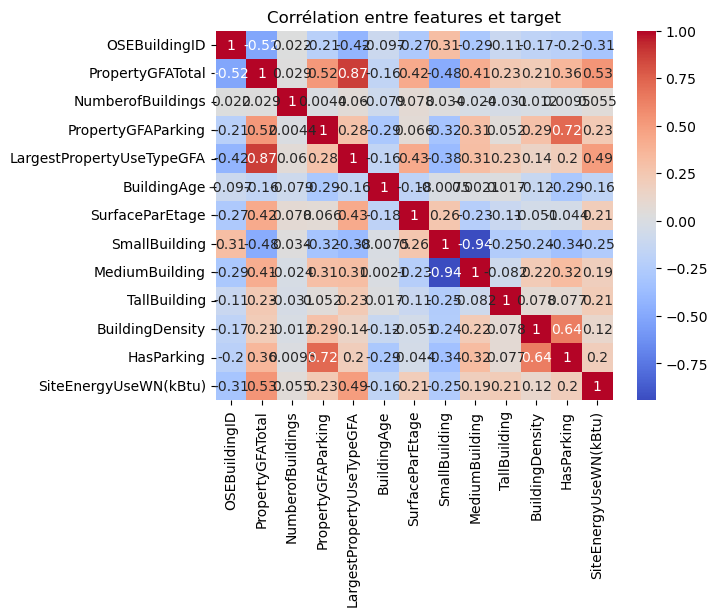

In [31]:
# Vérifier corrélation
corr_matrix = df_filtré[features_num + [target]].corr()
print("Matrice de corrélation :\n", corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation entre features et target")
plt.show()

## 🔍 Corrélation entre les variables

| Relation | Corrélation | Interprétation |
|-----------|--------------|----------------|
| PropertyGFATotal ↔ SiteEnergyUse(kBtu) | **0.53** | Corrélation moyenne positive |
| LargestPropertyUseTypeGFA ↔ SiteEnergyUse(kBtu) | **0.49** | Corrélation moyenne positive |
| BuildingAge ↔ SiteEnergyUse(kBtu) | **-0.17** | Corrélation faible |


🔴 Rouge = corrélation forte  
🔵 Bleu = corrélation faible  

**Conclusion :**  
> La taille du bâtiment (PropertyGFATotal) influence le plus la consommation d’énergie.


In [32]:
#supprimer les features a faible correlation :  
df_filtré.drop(columns=["OSEBuildingID","NumberofBuildings"], inplace=True)
numeric_cols_final = df_filtré.select_dtypes(include=["number"]).columns.tolist()

# Retirer la target
features_num_final = [col for col in numeric_cols_final if col != target]
display(df_filtré.columns)

Index(['PrimaryPropertyType', 'PropertyGFATotal', 'SiteEnergyUseWN(kBtu)',
       'LargestPropertyUseType', 'Neighborhood', 'PropertyGFAParking',
       'LargestPropertyUseTypeGFA', 'BuildingAge', 'SurfaceParEtage',
       'SmallBuilding', 'MediumBuilding', 'TallBuilding', 'BuildingDensity',
       'AgeCategory', 'HasParking'],
      dtype='object')

### Préparation du jeu de données pour la modélisation

À présent que nous avons enrichi notre DataFrame avec de nouvelles variables, 
nous allons le préparer pour l'entraînement d’un modèle : 

- Encodage des variables catégorielles
- Normalisation des variables numériques
- Séparation entraînement / test
- Sélection des variables explicatives (`X`)
- Définition de la variable cible (`y`)


In [33]:
# 🔹 Variables catégorielles
# -----------------------------
cat_cols = ['PrimaryPropertyType', 'LargestPropertyUseType','Neighborhood','AgeCategory']

# Limiter aux 10 catégories les plus fréquentes
for col in cat_cols:
    top_categories = df_filtré[col].value_counts().nlargest(10).index
    df_filtré[col] = df_filtré[col].apply(lambda x: x if x in top_categories else 'Other')

# One-Hot Encoding
df_encoded = pd.get_dummies(df_filtré, columns=cat_cols, drop_first=True)

# Supprimer les lignes avec NaN
df_encoded = df_encoded.dropna()
print("Shape après encodage et nettoyage :", df_encoded.shape)
print(df_encoded.head())

Shape après encodage et nettoyage : (1304, 41)
   PropertyGFATotal  SiteEnergyUseWN(kBtu)  PropertyGFAParking  \
0             88434              7456910.0                   0   
1            103566              8664479.0               15064   
2             61320              6946800.5                   0   
3            175580             14656503.0               62000   
4             97288             12581712.0               37198   

   LargestPropertyUseTypeGFA  BuildingAge  SurfaceParEtage  SmallBuilding  \
0                    88434.0           89      7369.500000              0   
1                    83880.0           20      9415.090909              0   
2                    61320.0           90      6132.000000              0   
3                   123445.0           36      9754.444444              0   
4                    88830.0           17     48644.000000              1   

   MediumBuilding  TallBuilding  BuildingDensity  ...  Neighborhood_EAST  \
0               0

### Résumé :
 - Le DataFrame filtré contient maintenant les colonnes originales pertinentes ainsi que des features nouvelles.
 - Les nouvelles features incluent le nombre d'étages en catégories, et des colonnes binaire pour le type    principal d'usage.
 - Ces features pourront être utilisées pour la modélisation sans risque de data leakage.
 - Les features ayant une corrélation faible ou négligeable avec la cible ont été retirées du dataset.

Le DataFrame final contient donc uniquement les variables pertinentes et non redondantes, prêtes pour l’étape de modélisation.

In [34]:
# -----------------------------
# ✅ 1️⃣ Séparation features / cible
# -----------------------------
target = "SiteEnergyUseWN(kBtu)"
X = df_encoded.drop(columns=target)
y = df_encoded[target]

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Taille train :", X_train.shape, "Taille test :", X_test.shape)


Taille train : (1043, 40) Taille test : (261, 40)


In [18]:
display(X.columns)
display(X.head())

Index(['PropertyGFATotal', 'PropertyGFAParking', 'LargestPropertyUseTypeGFA',
       'BuildingAge', 'SurfaceParEtage', 'SmallBuilding', 'MediumBuilding',
       'TallBuilding', 'BuildingDensity', 'HasParking',
       'PrimaryPropertyType_Hotel', 'PrimaryPropertyType_K-12 School',
       'PrimaryPropertyType_Large Office',
       'PrimaryPropertyType_Mixed Use Property', 'PrimaryPropertyType_Other',
       'PrimaryPropertyType_Retail Store',
       'PrimaryPropertyType_Small- and Mid-Sized Office',
       'PrimaryPropertyType_Warehouse', 'PrimaryPropertyType_Worship Facility',
       'LargestPropertyUseType_Hotel', 'LargestPropertyUseType_K-12 School',
       'LargestPropertyUseType_Non-Refrigerated Warehouse',
       'LargestPropertyUseType_Office', 'LargestPropertyUseType_Other',
       'LargestPropertyUseType_Other - Recreation',
       'LargestPropertyUseType_Retail Store',
       'LargestPropertyUseType_Supermarket/Grocery Store',
       'LargestPropertyUseType_Worship Facility', '

,PropertyGFATotal,PropertyGFAParking,LargestPropertyUseTypeGFA,BuildingAge,SurfaceParEtage,SmallBuilding,MediumBuilding,TallBuilding,BuildingDensity,HasParking,...,Neighborhood_EAST,Neighborhood_GREATER DUWAMISH,Neighborhood_LAKE UNION,Neighborhood_MAGNOLIA / QUEEN ANNE,Neighborhood_NORTH,Neighborhood_NORTHEAST,Neighborhood_NORTHWEST,Neighborhood_Other,AgeCategory_Moyen,AgeCategory_Vieux
0,88434,0,88434.0,89,7369.500000,0,0,1,0.000000,0,...,False,False,False,False,False,False,False,False,False,True
1,103566,15064,83880.0,20,9415.090909,0,0,1,6.875066,1,...,False,False,False,False,False,False,False,False,True,False
2,61320,0,61320.0,90,6132.000000,0,1,0,0.000000,0,...,False,False,False,False,False,False,False,False,False,True
3,175580,62000,123445.0,36,9754.444444,0,0,1,2.831935,1,...,False,False,False,False,False,False,False,False,True,False
4,97288,37198,88830.0,17,48644.000000,1,0,0,2.615409,1,...,False,False,False,False,False,False,False,False,False,False


In [35]:
# -----------------------------
# 2️⃣ Scaling pour modèles linéaires et SVR
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 🧩 Vérification et interprétation

- Le dataset a été séparé en **80 % pour l'entraînement** et **20 % pour le test**.  
- Toutes les variables numériques ont été **standardisées** :  
  - Moyenne ≈ 0  
  - Écart-type ≈ 1  
- Cette étape permet d'éviter qu'une variable ayant une grande échelle (ex. surface) domine les autres.

Le dataset est maintenant prêt pour la phase de **modélisation (entraînement du modèle)**.


# 🧠 Modélisation & Évaluation 

In [36]:

# KFold pour Cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# ================================
# 🧩 Étape 1 : Baseline - Linear Regression
# ================================
baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred = baseline_model.predict(X_train_scaled)
y_test_pred  = baseline_model.predict(X_test_scaled)

print("=== Linear Regression - Baseline ===")
print(f"Train → R²: {r2_score(y_train, y_train_pred):.3f}, RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}, MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test  → R²: {r2_score(y_test, y_test_pred):.3f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}, MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")


=== Linear Regression - Baseline ===
Train → R²: 0.493, RMSE: 2328364.07, MAE: 1586674.93
Test  → R²: 0.478, RMSE: 2456794.61, MAE: 1633150.79


In [37]:
# ================================
# 🧩 Étape 2 : Ridge et Lasso avec CV
# ================================
models = {
    "Ridge": Ridge(alpha=10, max_iter=50000 ,solver='saga'),
    "Lasso": Lasso(alpha=10, max_iter=10000,selection='cyclic') 
}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='r2')
    print(f"\n{name} - CV R² moyen = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred  = model.predict(X_test_scaled)
    print(f"{name} → Train R²: {r2_score(y_train, y_train_pred):.3f}, Test R²: {r2_score(y_test, y_test_pred):.3f}")



Ridge - CV R² moyen = 0.444 (+/- 0.051)
Ridge → Train R²: 0.493, Test R²: 0.481


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.614e+13, tolerance: 8.477e+11
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.860e+12, tolerance: 8.517e+11
  model = cd_fast.enet_coordinate_descent(



Lasso - CV R² moyen = 0.442 (+/- 0.053)
Lasso → Train R²: 0.493, Test R²: 0.478


In [49]:
# ================================
# 🧩 Étape 3 : Modèles avancés (non linéaires) avec Cross-Validation
# ================================
advanced_models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
}

feature_importances_dict = {}  # Pour stocker toutes les importances

for name, model in advanced_models.items():

    # 🎯 Cross-validation (R²)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    print(f"\n{name} → CV R² moyen : {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

    # 🎯 Entraînement complet
    model.fit(X_train, y_train)

    # 📌 Feature importances si disponibles
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_importances_dict[name] = dict(zip(X_train.columns, importances))

    # 🎯 R² train et test
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(f"{name} → Train R²: {r2_score(y_train, y_train_pred):.3f}, Test R²: {r2_score(y_test, y_test_pred):.3f}")

# ================================
# 📊 Affichage global des importances
# ================================
print("\n📊 Feature importances globales par modèle :")
for model_name, feat_imp in feature_importances_dict.items():
    print(f"\n{model_name}:")
    for f, imp in sorted(feat_imp.items(), key=lambda x: x[1], reverse=True):
        print(f"{f}: {imp:.4f}")



Random Forest → CV R² moyen : 0.397 (+/- 0.043)
Random Forest → Train R²: 0.918, Test R²: 0.499

XGBoost → CV R² moyen : 0.436 (+/- 0.058)
XGBoost → Train R²: 0.603, Test R²: 0.494

📊 Feature importances globales par modèle :

Random Forest:
PropertyGFATotal: 0.3870
LargestPropertyUseTypeGFA: 0.1347
LargestPropertyUseType_Supermarket/Grocery Store: 0.0871
SurfaceParEtage: 0.0856
BuildingAge: 0.0694
PrimaryPropertyType_Other: 0.0223
LargestPropertyUseType_Non-Refrigerated Warehouse: 0.0222
BuildingDensity: 0.0211
PropertyGFAParking: 0.0160
LargestPropertyUseType_Other: 0.0156
PrimaryPropertyType_Warehouse: 0.0142
Neighborhood_Other: 0.0135
Neighborhood_EAST: 0.0086
Neighborhood_GREATER DUWAMISH: 0.0082
Neighborhood_NORTHWEST: 0.0078
Neighborhood_DOWNTOWN: 0.0075
AgeCategory_Moyen: 0.0070
Neighborhood_MAGNOLIA / QUEEN ANNE: 0.0066
LargestPropertyUseType_Other - Recreation: 0.0060
Neighborhood_NORTHEAST: 0.0057
Neighborhood_LAKE UNION: 0.0052
LargestPropertyUseType_Office: 0.0048
TallBui

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


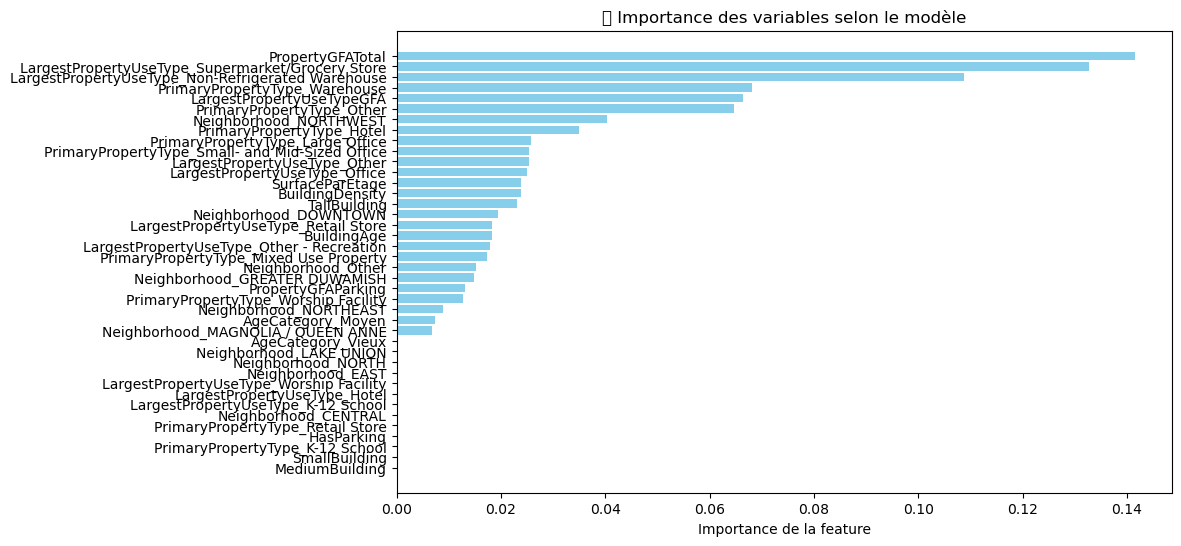

In [50]:

features = X_train.columns

# 3️⃣ Trier par importance décroissante
indices = importances.argsort()[::-1]  # indices triés
sorted_importances = importances[indices]
sorted_features = features[indices]

# 4️⃣ Afficher graphiquement
plt.figure(figsize=(10,6))
plt.barh(sorted_features, sorted_importances, color='skyblue')
plt.xlabel("Importance de la feature")
plt.title("📊 Importance des variables selon le modèle")
plt.gca().invert_yaxis()  # La plus importante en haut
plt.show()


In [51]:
# ================================
# 🧩 Étape 4 : Hyperparameter tuning GridSearchCV pour RF et XGBoost
# ================================
# Random Forest
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ['sqrt', 'log2']
}

rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=kfold, scoring='r2', n_jobs=-1)
rf_gs.fit(X_train, y_train)
best_rf = rf_gs.best_estimator_
y_train_pred = best_rf.predict(X_train)
y_test_pred  = best_rf.predict(X_test)
print(f"\nRandom Forest Meilleurs params: {rf_gs.best_params_}")
print(f"RF → Train R²: {r2_score(y_train, y_train_pred):.3f}, Test R²: {r2_score(y_test, y_test_pred):.3f}")

# XGBoost
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8]
}

xgb_gs = GridSearchCV(XGBRegressor(random_state=42), xgb_param_grid, cv=kfold, scoring='r2', n_jobs=-1)
xgb_gs.fit(X_train, y_train)
best_xgb = xgb_gs.best_estimator_
y_train_pred = best_xgb.predict(X_train)
y_test_pred  = best_xgb.predict(X_test)
print(f"\nXGBoost Meilleurs params: {xgb_gs.best_params_}")
print(f"XGB → Train R²: {r2_score(y_train, y_train_pred):.3f}, Test R²: {r2_score(y_test, y_test_pred):.3f}")



Random Forest Meilleurs params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
RF → Train R²: 0.659, Test R²: 0.497

XGBoost Meilleurs params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6}
XGB → Train R²: 0.611, Test R²: 0.487


# Évaluation

In [52]:
# ================================
# 🧩 Étape : Évaluation finale du meilleur modèle
# ================================
# On choisit le meilleur modèle selon Test R²
models_test_r2 = {
    "Baseline": r2_score(y_test, baseline_model.predict(X_test_scaled)),
    "Ridge": r2_score(y_test, Ridge(alpha=1.0).fit(X_train_scaled, y_train).predict(X_test_scaled)),
    "Lasso": r2_score(y_test, Lasso(alpha=0.001).fit(X_train_scaled, y_train).predict(X_test_scaled)),
    "Random Forest RF": r2_score(y_test, best_rf.predict(X_test)),
    "XGBoost XGB": r2_score(y_test, best_xgb.predict(X_test))
}
best_model_name = max(models_test_r2, key=models_test_r2.get)
print(f"\n✅ Meilleur modèle global selon Test R² : {best_model_name}")


✅ Meilleur modèle global selon Test R² : Random Forest RF


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.827e+15, tolerance: 1.116e+12
  model = cd_fast.enet_coordinate_descent(


In [53]:
# ==============================================================
# 🚀 Comparaison de modèles
# ==============================================================

models = {
    "Régression Linéaire (Baseline)": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Random Forest RF": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost XGB": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    "SVR (RBF Kernel)": SVR(kernel='rbf', C=10, epsilon=0.1)
}

results = []

for name, model in models.items():
    res = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append(res)

# --- Tableau comparatif ---
results_df = pd.DataFrame(results).sort_values(by="Test_R2", ascending=False)
display(results_df)



=== Régression Linéaire (Baseline) ===
CV R² moyen : 0.443 (+/- 0.060)
Train R² : 0.493 | Test R² : 0.478
Test MAE : 1,633,151 | Test RMSE : 2,456,795

=== Ridge ===
CV R² moyen : 0.443 (+/- 0.060)
Train R² : 0.493 | Test R² : 0.479
Test MAE : 1,633,182 | Test RMSE : 2,455,938


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.254e+15, tolerance: 8.962e+11
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.136e+15, tolerance: 8.434e+11
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.231e+15, toleranc


=== Lasso ===
CV R² moyen : 0.443 (+/- 0.061)
Train R² : 0.493 | Test R² : 0.478
Test MAE : 1,633,430 | Test RMSE : 2,456,754

=== Random Forest RF ===
CV R² moyen : 0.426 (+/- 0.020)
Train R² : 0.918 | Test R² : 0.499
Test MAE : 1,613,773 | Test RMSE : 2,407,204

=== XGBoost XGB ===
CV R² moyen : 0.437 (+/- 0.055)
Train R² : 0.678 | Test R² : 0.472
Test MAE : 1,618,342 | Test RMSE : 2,471,541

=== SVR (RBF Kernel) ===
CV R² moyen : -0.150 (+/- 0.013)
Train R² : -0.147 | Test R² : -0.192
Test MAE : 2,383,206 | Test RMSE : 3,713,851


,Modèle,CV_R2_Moyen,Train_R2,Test_R2,Test_MAE,Test_RMSE
3,Random Forest RF,0.426169,0.917555,0.499081,1.613773e+06,2.407204e+06
1,Ridge,0.443137,0.493297,0.478593,1.633182e+06,2.455938e+06
2,Lasso,0.442907,0.493360,0.478246,1.633430e+06,2.456754e+06
0,Régression Linéaire (Baseline),0.443084,0.493395,0.478229,1.633151e+06,2.456795e+06
4,XGBoost XGB,0.436892,0.677669,0.471947,1.618342e+06,2.471541e+06
5,SVR (RBF Kernel),-0.150140,-0.147471,-0.192315,2.383206e+06,3.713851e+06


# Sauvegarde du modèle avec BentoML

In [54]:
best_model = models[best_model_name]

In [55]:
display(best_model)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
# -----------------------------
# 4️⃣ Pipeline finale pour BentoML
# -----------------------------
# On conserve le scaler pour les numériques et l'encodage OneHot pour les catégorielles
preprocessor = ColumnTransformer(
   transformers=[
        ("num", StandardScaler(), features_num_final),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])
# -----------------------------
display(df_filtré.columns)
df_filtré = df_filtré.dropna(subset=[target])
X1 = df_filtré.drop(columns=target)
y1 = df_filtré[target]
# Supprimer les lignes où la cible est NaN


# Split train / test
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)
print("Taille train :", X1_train.shape, "Taille test :", X1_test.shape)
print("Nombre de NaN dans y_train :", y_train.isna().sum())
# Entraînement complet sur train
pipeline.fit(X1_train, y1_train)

# -----------------------------
# 5️⃣ Sauvegarde avec BentoML
# -----------------------------
saved_model = bentoml.sklearn.save_model("best_energy_model", pipeline)
print(f"Modèle sauvegardé BentoML : {saved_model}")

Index(['PrimaryPropertyType', 'PropertyGFATotal', 'SiteEnergyUseWN(kBtu)',
       'LargestPropertyUseType', 'Neighborhood', 'PropertyGFAParking',
       'LargestPropertyUseTypeGFA', 'BuildingAge', 'SurfaceParEtage',
       'SmallBuilding', 'MediumBuilding', 'TallBuilding', 'BuildingDensity',
       'AgeCategory', 'HasParking'],
      dtype='object')

Taille train : (1046, 14) Taille test : (262, 14)
Nombre de NaN dans y_train : 0
Modèle sauvegardé BentoML : Model(tag="best_energy_model:z7jxrvof62g4fpax")


In [57]:
display(pipeline)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
